# The CMB, Computed Rather Than Compressed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/01-getting-started/cmb_from_scratch.ipynb)

Most dark-energy work uses the CMB through **compressed distance
priors**: three numbers (`R`, `l_A`, `omega_b h²`) compared against
a background `E(z)`. That is the `"planck"` dataset. It is free,
needs no extra dependency, works for every model in the library, and
is what most papers do.

It also throws almost all of the information away, and it carries
every convention of whoever produced the compression.

`"planck_lite"` is the other end of that trade: **613 measured
TT/TE/EE bandpowers** with their full covariance, compared against a
`C_l` spectrum computed from scratch by CAMB. No compression, no
derived summary, no borrowed convention — the theory prediction is
the same object the data is.

This notebook is the short tour: what it costs, what it needs, and
one fit that reproduces Planck 2018. It runs in about ten minutes,
almost all of it in CAMB.

For the CMB used in earnest — the low-ℓ EE table, lensing, σ₈
*derived* and confronted with weak lensing — see
[`../05-case-studies/s8_tension_cmb.ipynb`](../05-case-studies/s8_tension_cmb.ipynb).

## Setup

This one genuinely needs the `cmb` extra.

In [ ]:
import sys

# On Colab, install the released package and nothing else.
#
# This used to clone the repository and install it editable,
# which needed a `sys.path` fix afterwards: pip runs in a
# subprocess, so the already-running kernel never saw the .pth
# file it wrote, and `import CosmoFit` could resolve to the bare
# checkout directory instead -- same name, and /content is on
# sys.path. A normal install goes to site-packages, which is
# already there, so all of that goes away.

if "google.colab" in sys.modules:
    !pip install -q "cosmofit[cmb]"
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          'installed (pip install "cosmofit[cmb]").')


In [2]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Fitter, LCDM

plt.rcParams["figure.dpi"] = 110

try:
    import camb
    print(f"CAMB {camb.__version__}")
except ImportError:
    raise SystemExit("This notebook needs CAMB: pip install 'cosmofit[cmb]'")

CAMB 2.0.4


## 1. The two ends of one trade

Same experiment, two ways of using it. The difference in what you
get, and what it costs, is worth seeing as numbers.

In [3]:
FIDUCIAL = dict(
    H0=67.36, Omega_m=0.3153, Omega_b=0.04930, rd=147.09,
    n_s=0.9649, ln1e10As=3.044, tau_reio=0.0544, A_planck=1.0,
)

compressed = Fitter(model=LCDM, datasets=["planck"],
                    free_params=["H0", "Omega_m", "Omega_b"],
                    initial=FIDUCIAL)

computed = Fitter(model=LCDM, datasets=["planck_lite"],
                  free_params=["H0", "Omega_m", "Omega_b", "ln1e10As", "n_s"],
                  initial=FIDUCIAL)


def cost(fit, n):
    """Milliseconds per *new* parameter point (a repeat is cached)."""

    fit.chi2()
    rng = np.random.default_rng(0)
    points = [fit.theta0 * (1 + 1e-3 * rng.normal(size=fit.theta0.size))
              for _ in range(n)]

    start = time.perf_counter()
    for theta in points:
        fit.logpost.chi2(theta)
    return (time.perf_counter() - start) / n * 1e3


for label, fit, n in [("planck (compressed)", compressed, 200),
                      ("planck_lite (computed)", computed, 3)]:
    print(f"{label:24s}  n_data={fit.n_data:4d}   "
          f"{cost(fit, n):9.1f} ms per evaluation")

planck (compressed)       n_data=   3         0.2 ms per evaluation


planck_lite (computed)    n_data= 613       766.4 ms per evaluation


Three orders of magnitude. That is not an implementation flaw — it
is a Boltzmann code solving the perturbation equations, and it is
why compressed priors exist and why full CMB chains run on
clusters.

Budget accordingly: a 3000-step chain that would take two minutes
with compressed priors takes **days** with this. Everything below
therefore uses `best_fit` and a Fisher matrix rather than an MCMC —
which turns out to be enough.

## 2. What it will not do

CAMB solves the perturbation equations of General Relativity. A
model that changes those equations cannot be handed to it, and the
library refuses rather than silently returning GR perturbations for
a modified-gravity theory.

In [4]:
from CosmoFit.cosmology.models import FQExponential

try:
    Fitter(model=FQExponential, datasets=["planck_lite"],
           free_params=["H0", "Omega_m"], initial=FIDUCIAL)
except Exception as exc:
    print(f"{type(exc).__name__}:\n{exc}")

BoltzmannError:
Cannot compute CMB spectra for FQExponential: f(Q) gravity modifies the field equations themselves; CAMB's perturbation solver assumes GR.
Use the compressed distance priors (datasets=['planck', ...]) for this model instead -- they need only E(z).


So `planck_lite` covers ΛCDM and anything exposing a `w(z)`. For
the rest, the compressed priors are the honest option — they only
ever needed `E(z)`.

## 3. The parameter it cannot pin on its own

A CMB spectrum depends on three things a background fit never
needed: the primordial amplitude and tilt (`ln1e10As`, `n_s`) and
the reionization optical depth (`tau_reio`).

But `plik_lite` starts at `l = 30`, and reionization's signature is
a bump in EE at `l < 30`. What the high-ℓ spectrum actually
constrains is the combination `A_s e^{-2 tau}` — so `tau` and the
amplitude slide against each other almost freely.

In [5]:
alone = Fitter(model=LCDM, datasets=["planck_lite"],
               free_params=["ln1e10As", "tau_reio"], initial=FIDUCIAL)

base = alone.chi2()

print(f"{'tau':>8s} {'A_s held fixed':>22s} {'A_s exp(-2 tau) held fixed':>28s}")

for tau in (0.0544, 0.0800, 0.1100):

    on_its_own = alone.logpost.chi2(
        np.array([FIDUCIAL["ln1e10As"], tau])
    )

    # The combination the damping tail actually measures.
    compensated = alone.logpost.chi2(
        np.array([FIDUCIAL["ln1e10As"] + 2.0 * (tau - FIDUCIAL["tau_reio"]), tau])
    )

    print(f"{tau:8.4f} {on_its_own:12.2f} ({on_its_own - base:+8.2f}) "
          f"{compensated:16.2f} ({compensated - base:+7.2f})")

     tau         A_s held fixed   A_s exp(-2 tau) held fixed
  0.0544       584.03 (   +0.00)           584.03 (  +0.00)


  0.0800      1601.95 (+1017.93)           580.17 (  -3.85)


  0.1100      5145.97 (+4561.94)           578.95 (  -5.08)


Read the two columns against each other. Moving `tau` **on its
own** to twice its value costs **+4562** in chi-squared: the
high-multipole spectrum notices immediately. Moving it the same
distance while `A_s exp(-2 tau)` is held fixed costs **-5** — which
is to say nothing at all, and if anything the data would rather
`tau` were larger.

So `plik_lite` measures that *combination* superbly and the two
parameters separately not at all. Left alone, a fit slides along
this direction until it hits a prior bound.

Two ways to close it:

- **`"tau"`** — the Gaussian shorthand, `tau = 0.0544 ± 0.0073`.
  Free, and what most papers use.
- **`"planck_lowe"`** — the actual low-ℓ EE likelihood, a *tabulated*
  non-Gaussian one, which is what the shorthand is a compression of.
  Needs CAMB as well, and represents the skewness.

They must never both be in a fit — the same measurement twice — and
`Fitter` refuses the combination. This notebook takes the cheap
route; the case study takes the real one.

## 4. The fit

Six parameters, the standard ΛCDM set a CMB fit needs. This is the
slow cell — a few hundred CAMB calls, around seven minutes.

In [6]:
FREE = ["H0", "Omega_m", "Omega_b", "ln1e10As", "n_s", "tau_reio"]

fit = Fitter(model=LCDM, datasets=["planck_lite", "tau"],
             free_params=FREE, initial=FIDUCIAL)

print(f"{fit.n_data} data points\n")

start = time.perf_counter()
best = fit.best_fit(restarts=0, seed=0)
elapsed = time.perf_counter() - start

for name, value in zip(FREE, best.x):
    print(f"  {name:10s} = {value: .5f}")
print(f"\n  chi2 = {best.fun:.2f} / {fit.n_data} points")
print(f"  took {elapsed:.0f} s")

614 data points


/home/talos/miniconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


/home/talos/CosmoFit/src/CosmoFit/stats/fitter.py:2332: UserWarning: best_fit() did not move from its starting point: L-BFGS-B's default finite-difference step (~1.5e-8) is too small for this likelihood to respond to, which happens when a Boltzmann code's own numerical noise exceeds the chi2 change such a step produces. Retrying with Nelder-Mead, which needs no gradient. This is slower; pass `method=` or `eps=` to control it.
  result = self._single_best_fit(x0, bounds, options, eps, method)


  H0         =  67.09287
  Omega_m    =  0.31887
  Omega_b    =  0.04964
  ln1e10As   =  3.05358
  n_s        =  0.96301
  tau_reio   =  0.05870
  chi2 = 582.97 / 614 points
  took 431 s


**That warning is the point, not a fault.** L-BFGS-B's default
finite-difference step is about `1.5e-8`, and CAMB's own numerical
noise is larger than the chi-squared change such a step produces —
so the gradient it computes is noise, and the optimizer does not
move. `best_fit` detects that it went nowhere and retries with
Nelder-Mead, which needs no gradient. Slower, and correct.

This is a general hazard of optimizing against a Boltzmann code.
`fisher()` faces the same one and takes a `steps=` argument for it;
its default happened to be large enough here, which the comparison
against Planck's published uncertainties below is what
confirms.

### Against Planck's own numbers

None of these is an input anywhere above.

In [7]:
PLANCK_2018 = {          # TT,TE,EE+lowE+lensing
    "H0": (67.36, 0.54),
    "Omega_m": (0.3153, 0.0073),
    "ln1e10As": (3.044, 0.014),
    "n_s": (0.9649, 0.0042),
    "tau_reio": (0.0544, 0.0073),
}

fitted = dict(zip(FREE, best.x))

print(f"{'parameter':>10s} {'this fit':>10s} {'Planck 2018':>12s} {'difference':>12s}")
for name, (published, sigma) in PLANCK_2018.items():
    delta = (fitted[name] - published) / sigma
    print(f"{name:>10s} {fitted[name]:10.5f} {published:12.4f} {delta:+10.2f} sigma")

omega_b_h2 = fitted["Omega_b"] * (fitted["H0"] / 100.0) ** 2
print(f"{'omega_b h2':>10s} {omega_b_h2:10.5f} {0.02237:12.5f}")

 parameter   this fit  Planck 2018   difference
        H0   67.09287      67.3600      -0.49 sigma
   Omega_m    0.31887       0.3153      +0.49 sigma
  ln1e10As    3.05358       3.0440      +0.68 sigma
       n_s    0.96301       0.9649      -0.45 sigma
  tau_reio    0.05870       0.0544      +0.59 sigma
omega_b h2    0.02234      0.02237


Every one inside 0.7σ — from TT/TE/EE and a Gaussian `tau` prior
alone, with no lensing and no low-ℓ temperature. The remaining
offsets are what those missing components would have supplied; the
case study, which includes them, lands inside 0.16σ.

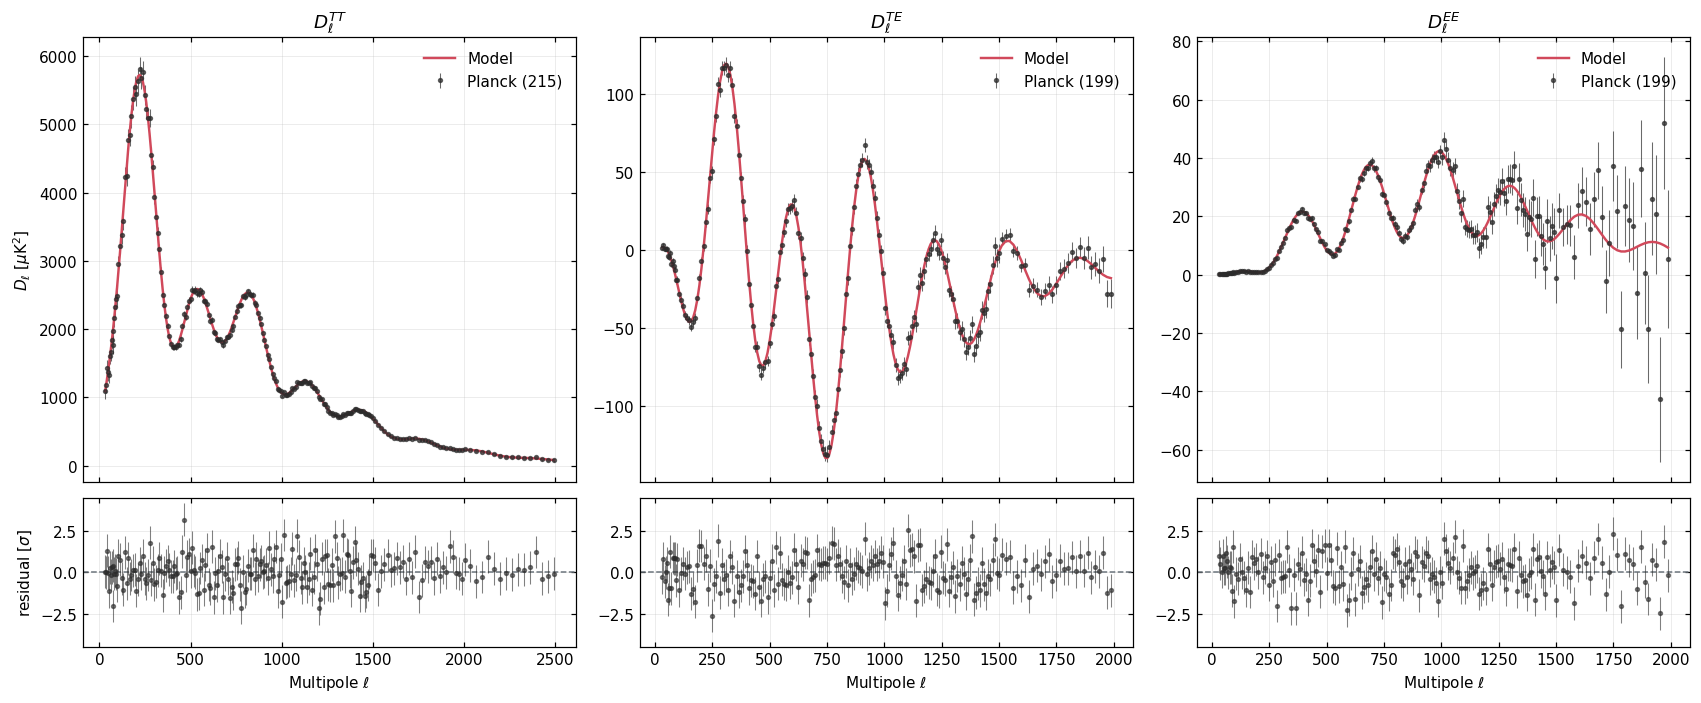

In [8]:
fit.plots.cmb_spectra();

## 5. Error bars without a chain

An MCMC here would take days. A Fisher matrix takes about `2n²`
likelihood evaluations — under a hundred, a minute — and for a
posterior this close to Gaussian that is enough.

In [9]:
start = time.perf_counter()
fisher = fit.fisher()
print(f"fisher: {time.perf_counter() - start:.0f} s\n")

print(f"{'parameter':>10s} {'Fisher':>10s} {'Planck 2018':>12s} {'ratio':>8s}")
for name, sigma in zip(FREE, fisher["errors"]):
    published = PLANCK_2018.get(name, (None, None))[1]
    if published is None:
        print(f"{name:>10s} {sigma:10.5f} {'--':>12s}")
    else:
        print(f"{name:>10s} {sigma:10.5f} {published:12.4f} "
              f"{sigma / published:8.2f}")

fisher: 60 s
 parameter     Fisher  Planck 2018    ratio
        H0    0.50185       0.5400     0.93
   Omega_m    0.00708       0.0073     0.97
   Omega_b    0.00059           --
  ln1e10As    0.01415       0.0140     1.01
       n_s    0.00401       0.0042     0.96
  tau_reio    0.00703       0.0073     0.96


That is Planck's published uncertainty budget, reproduced in a
minute by a matrix of second derivatives. See
[`../04-inference/profile_likelihood_and_fisher.ipynb`](../04-inference/profile_likelihood_and_fisher.ipynb)
for when this stops being trustworthy — a skewed posterior, or a
parameter against a boundary.

## 6. So when are the compressed priors enough?

Often. Fit the same background parameters both ways and compare.

In [10]:
quick = Fitter(model=LCDM, datasets=["planck"],
               free_params=["H0", "Omega_m", "Omega_b"],
               initial=FIDUCIAL)

start = time.perf_counter()
quick_best = quick.best_fit(restarts=3, seed=0)
quick_time = time.perf_counter() - start

quick_params = dict(zip(quick.free_params, quick_best.x))

print(f"{'parameter':>10s} {'compressed':>12s} {'computed':>12s} {'diff':>10s}")
for name in ("H0", "Omega_m", "Omega_b"):
    a, b = quick_params[name], fitted[name]
    print(f"{name:>10s} {a:12.5f} {b:12.5f} {a - b:+10.5f}")

print(f"\ncompressed: {quick_time:6.1f} s     computed: {elapsed:6.0f} s")

 parameter   compressed     computed       diff
        H0     67.26319     67.09287   +0.17032
   Omega_m      0.31635      0.31887   -0.00252
   Omega_b      0.04942      0.04964   -0.00022
compressed:    0.2 s     computed:    431 s


For the *geometry* they agree closely, which is exactly what the
compression was built to preserve — and why it is the right tool for
a dark-energy background fit.

Where it stops working is anything the three numbers cannot see.
The clearest case: **the compressed priors are blind to the neutrino
mass by construction.** Their `z_star` is a fitting formula
calibrated at the fiducial Σm_ν = 0.06 eV.

In [11]:
cosmology = LCDM(LCDM.PARAMS_CLASS(H0=67.36, Omega_m=0.3153, Omega_b=0.0493))

print(f"{'m_nu [eV]':>10s} {'z_star':>14s}")
for m_nu in (0.0, 0.06, 0.30, 0.80):
    cosmology.params.m_nu = m_nu
    cosmology.refresh()
    print(f"{m_nu:10.2f} {cosmology.recombination.z_star():14.6f}")

print("\nIdentical. A fit that frees m_nu against these priors is")
print("measuring nothing, and Fitter warns about exactly that.")

 m_nu [eV]         z_star
      0.00    1089.911912
      0.06    1089.911912
      0.30    1089.911912
      0.80    1089.911912
Identical. A fit that frees m_nu against these priors is
measuring nothing, and Fitter warns about exactly that.


In [12]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    Fitter(model=LCDM, datasets=["cc", "desi", "planck"],
           free_params=["H0", "Omega_m", "m_nu", "rd"],
           initial={**FIDUCIAL, "m_nu": 0.06})

for warning in caught:
    print(str(warning.message).split("\n")[0])

`m_nu` is a free parameter, but this fit has no CMB likelihood that can respond to it -- it reaches nothing at all.


## Which to use

**Compressed (`"planck"`)** for a background dark-energy fit: any
model, no dependency, milliseconds. It preserves the geometry, which
is what such a fit asks about.

**Computed (`"planck_lite"`)** when the question needs something the
three numbers do not carry — the primordial amplitude, the damping
tail, σ₈ derived rather than fitted, or the neutrino mass. Budget
CAMB's time, and reach for `best_fit` plus Fisher before an MCMC.

### Next

- [`../05-case-studies/s8_tension_cmb.ipynb`](../05-case-studies/s8_tension_cmb.ipynb)
  — the full version: low-ℓ EE as a tabulated likelihood, lensing,
  σ₈ derived and confronted with KiDS-1000 and DES Y3.
- [`dataset_zoo.ipynb`](dataset_zoo.ipynb) — all 21 datasets,
  including the other four CMB entries.
- [`../04-inference/profile_likelihood_and_fisher.ipynb`](../04-inference/profile_likelihood_and_fisher.ipynb)
  — when a Fisher matrix is and is not enough.